<a href="https://www.kaggle.com/code/avikdas567/global-earthquake-analytics-using-deep-learning?scriptVersionId=321300236" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Global Earthquake Analytics Using Deep Learning

This notebook explores more than 120 years of global earthquake activity using seismic records with magnitudes of 4.5 and above.

The analysis combines:

- Exploratory Data Analysis
- Statistical Analysis
- Geospatial Visualization
- Time Series Analysis
- Machine Learning
- Deep Learning
- Clustering
- Anomaly Detection
- Forecasting

The notebook investigates long-term seismic trends, earthquake depth behavior, geographic activity patterns, and the evolution of global earthquake reporting over time.

Several machine learning and deep learning models are also used to study seismic relationships and earthquake frequency patterns across historical records.

## Dataset Overview

The dataset contains global earthquake events with magnitudes greater than or equal to 4.5 from 1900 to the present.

Key attributes include:

- Event date and time
- Latitude and longitude
- Earthquake depth
- Magnitude and magnitude type
- Geographic location description
- Seismic station metadata
- Measurement quality indicators

The records are primarily sourced from the USGS Earthquake Hazards Program and related international seismic monitoring agencies.

In [1]:

import warnings
warnings.filterwarnings("ignore")

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import gc
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import MaxNLocator

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

sns.set_theme(style="whitegrid")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version:", tf.__version__)


E0000 00:00:1779436063.046752      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779436063.107718      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779436063.596692      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779436063.596746      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779436063.596748      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779436063.596751      23 computation_placer.cc:177] computation placer already registered. Please check linka

TensorFlow Version: 2.19.0


In [2]:

DATA_PATH = "/kaggle/input/datasets/belbino/global-earthquake-events-m4-5-1900-present/earthquakes.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (230805, 16)


,usgs_id,date,year,month,lat,lon,depth_km,magnitude,mag_type,magnitude_class,location_desc,review_status,n_stations,azimuthal_gap,min_station_dist,rms
0,cent19000105190000000,1900-01-05,1900,1,-3.0,102.0,NaN,7.0,ms,Major (M7-7.9),"Southern Sumatra, Indonesia",reviewed,NaN,NaN,NaN,NaN
1,cent19000111090700000,1900-01-11,1900,1,-5.0,148.0,NaN,7.0,ms,Major (M7-7.9),Bismarck Sea,reviewed,NaN,NaN,NaN,NaN
2,cent19000120063300000,1900-01-20,1900,1,20.0,-105.0,NaN,7.3,mw,Major (M7-7.9),"Jalisco, Mexico",reviewed,NaN,NaN,NaN,NaN
3,cent19000131192200000,1900-01-31,1900,1,48.0,146.0,450.0,7.5,mj,Major (M7-7.9),Sea of Okhotsk,reviewed,NaN,NaN,NaN,NaN
4,ushis389,1900-04-30,1900,4,36.9,-121.6,NaN,4.5,ml,Light (M4.5-4.9),"Near Aromas, California",reviewed,NaN,NaN,NaN,NaN



### Analysis

The dataset contains more than 230,000 earthquake records collected over a time span exceeding 120 years. 
This scale makes the dataset large enough for both statistical analysis and machine learning experimentation.

The feature set combines geospatial coordinates, seismic measurements, station-level metadata, and quality indicators, allowing both physical and observational analysis of earthquake behavior.



## Initial Inspection

Before building models or visualizations, it is useful to inspect missing values, feature distributions, and structural patterns in the catalogue.


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230805 entries, 0 to 230804
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   usgs_id           230805 non-null  object 
 1   date              230805 non-null  object 
 2   year              230805 non-null  int64  
 3   month             230805 non-null  int64  
 4   lat               230805 non-null  float64
 5   lon               230805 non-null  float64
 6   depth_km          230068 non-null  float64
 7   magnitude         230805 non-null  float64
 8   mag_type          230804 non-null  object 
 9   magnitude_class   230805 non-null  object 
 10  location_desc     230805 non-null  object 
 11  review_status     230805 non-null  object 
 12  n_stations        79682 non-null   float64
 13  azimuthal_gap     101621 non-null  float64
 14  min_station_dist  62282 non-null   float64
 15  rms               183332 non-null  float64
dtypes: float64(8), int64

In [4]:

missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="missing_values")
)

missing["missing_percent"] = (
    missing["missing_values"] / len(df) * 100
).round(2)

missing


,missing_values,missing_percent
min_station_dist,168523,73.02
n_stations,151123,65.48
azimuthal_gap,129184,55.97
rms,47473,20.57
depth_km,737,0.32
mag_type,1,0.00
year,0,0.00
usgs_id,0,0.00
magnitude,0,0.00
lon,0,0.00


In [5]:

df["date"] = pd.to_datetime(df["date"])

df["decade"] = (df["year"] // 10) * 10

df["depth_km"] = df["depth_km"].fillna(df["depth_km"].median())
df["n_stations"] = df["n_stations"].fillna(0)
df["azimuthal_gap"] = df["azimuthal_gap"].fillna(df["azimuthal_gap"].median())
df["min_station_dist"] = df["min_station_dist"].fillna(df["min_station_dist"].median())
df["rms"] = df["rms"].fillna(df["rms"].median())

df.describe().T


,count,mean,min,25%,50%,75%,max,std
date,230805,1997-06-12 12:18:29.362448896,1900-01-05 00:00:00,1984-06-28 00:00:00,1998-12-04 00:00:00,2014-03-21 00:00:00,2026-05-14 00:00:00,NaN
year,230805.0,1996.928797,1900.0,1984.0,1998.0,2014.0,2026.0,21.282295
month,230805.0,6.744928,1.0,4.0,7.0,10.0,12.0,3.415986
lat,230805.0,5.634714,-83.902,-16.071,1.773,31.1041,87.221,29.466226
lon,230805.0,42.655925,-179.9997,-71.082,101.6549,142.4195,180.0,120.60115
depth_km,230805.0,71.313942,-3.0,10.32,33.0,62.9,700.9,117.329442
magnitude,230805.0,4.965707,3.38,4.6,4.8,5.2,9.5,0.506384
n_stations,230805.0,27.04324,0.0,0.0,0.0,29.0,934.0,62.419449
azimuthal_gap,230805.0,91.567008,6.5,89.2,89.2,89.2,360.0,31.355562
min_station_dist,230805.0,3.083914,0.0,2.602,2.602,2.602,62.558,3.039678



### Analysis

The dataset is relatively clean considering its historical coverage. 
Most missing values appear in station-related fields and depth measurements from older events.

The distribution statistics show that:
- Most earthquakes are concentrated within the moderate magnitude range
- Deep-focus earthquakes are comparatively rare
- Station coverage varies heavily across decades due to technological improvements in seismic monitoring



## Earthquake Frequency Through Time

One of the most important long-term questions is whether recorded seismic activity has increased over time.

A visible rise in earthquake counts may indicate:

- Better seismic monitoring systems
- Increased station coverage
- Improved reporting infrastructure
- Real changes in tectonic activity


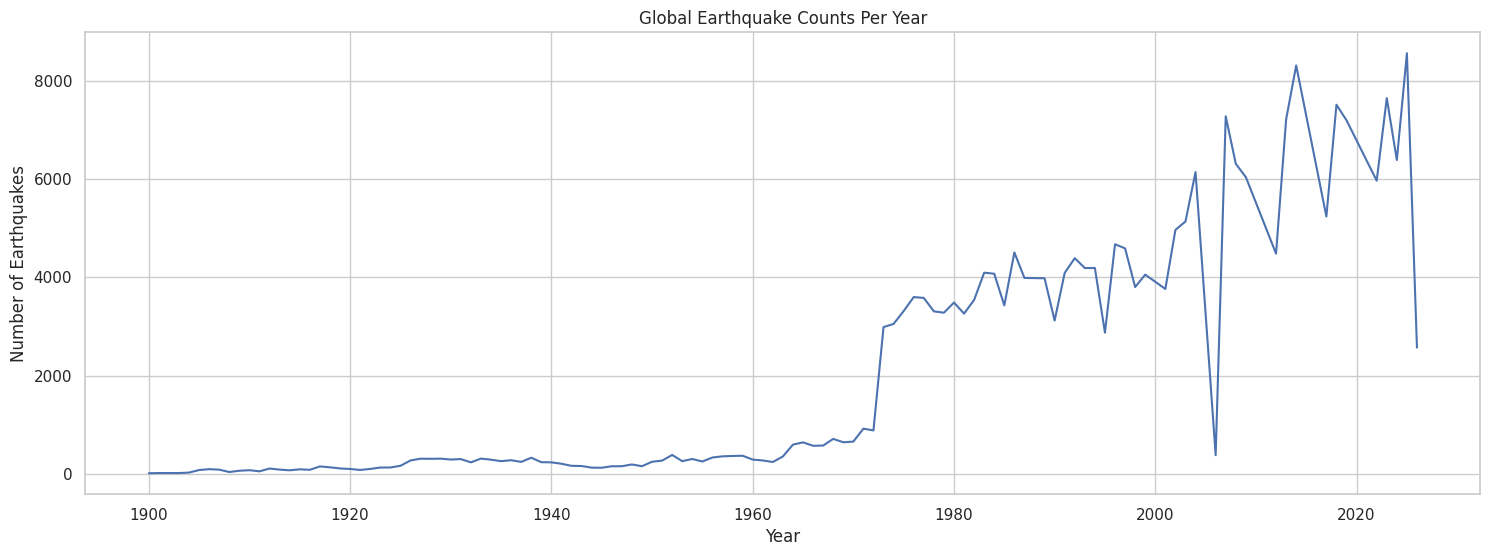

In [6]:

yearly_counts = df.groupby("year").size()

plt.figure(figsize=(18,6))
plt.plot(yearly_counts.index, yearly_counts.values, linewidth=1.5)
plt.title("Global Earthquake Counts Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Earthquakes")
plt.show()



### Analysis

The yearly trend reveals a major increase in recorded earthquakes after the mid-20th century.

This rise is unlikely to represent a pure increase in tectonic activity alone. A large portion of the growth is strongly linked to:
- Expansion of global seismic monitoring networks
- Better instrumentation
- Improved international reporting systems
- Increased station density


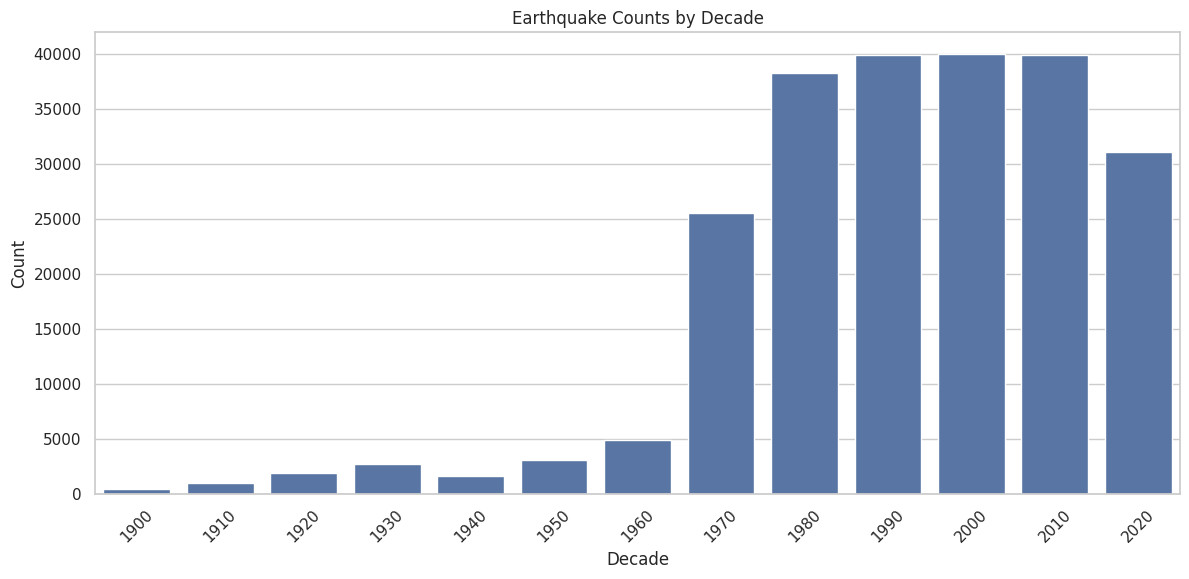

In [7]:

decade_counts = df.groupby("decade").size()

plt.figure(figsize=(14,6))
sns.barplot(
    x=decade_counts.index.astype(str),
    y=decade_counts.values
)

plt.xticks(rotation=45)
plt.title("Earthquake Counts by Decade")
plt.xlabel("Decade")
plt.ylabel("Count")
plt.show()



### Analysis

Decadal aggregation makes the long-term reporting shift even clearer.

Early decades contain relatively sparse records, while modern decades show a sharp increase in event density. 
This pattern reflects how modern seismic infrastructure dramatically improved global earthquake detection capability.



## Magnitude Distribution

The distribution of magnitudes reveals whether the catalogue is dominated by moderate events or extreme seismic episodes.


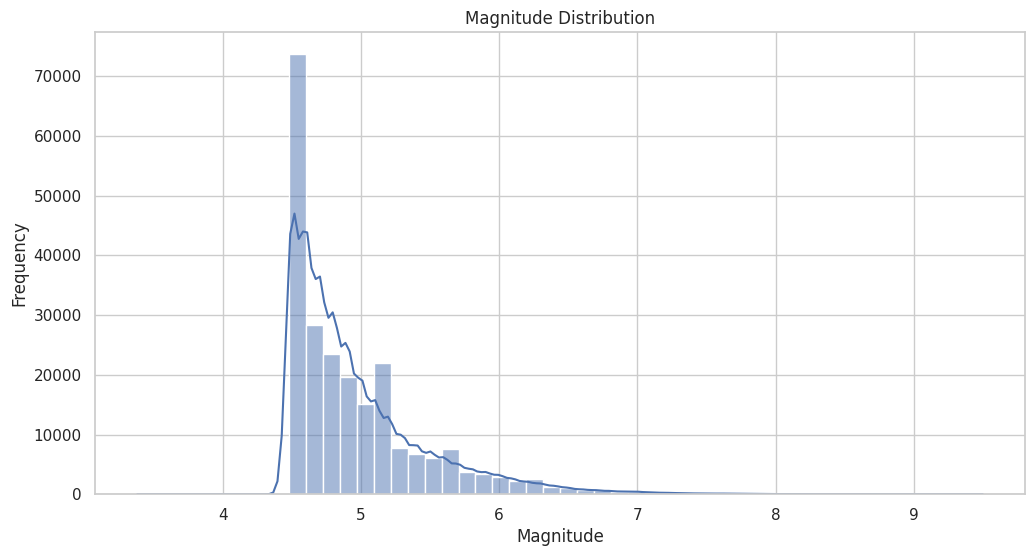

In [8]:

plt.figure(figsize=(12,6))

sns.histplot(
    df["magnitude"],
    bins=50,
    kde=True
)

plt.title("Magnitude Distribution")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()



### Analysis

The magnitude distribution is heavily right-skewed.

Most earthquakes fall within the lower end of the dataset threshold near magnitude 4.5 to 5.5. 
Extremely large earthquakes are naturally rare, which aligns with known seismic scaling laws such as the Gutenberg-Richter relationship.


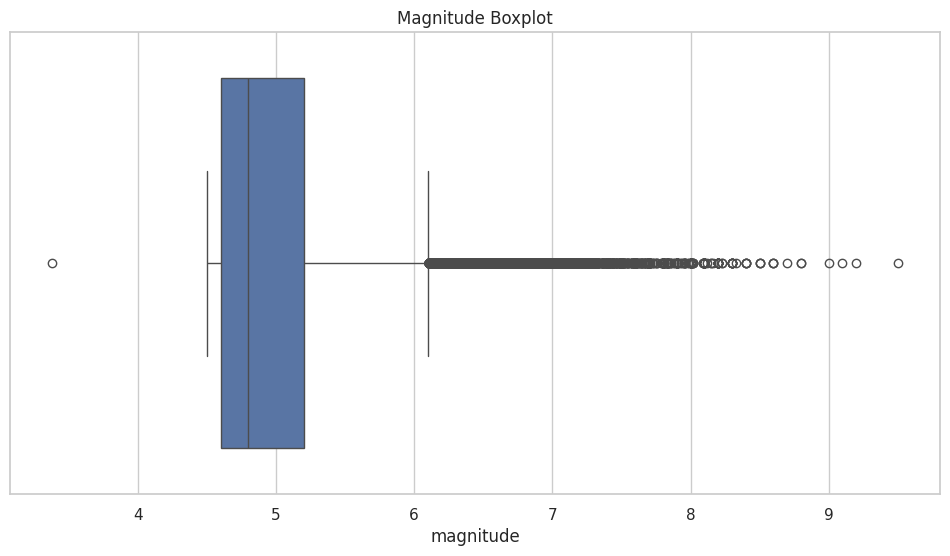

In [9]:

plt.figure(figsize=(12,6))

sns.boxplot(x=df["magnitude"])

plt.title("Magnitude Boxplot")
plt.show()



### Analysis

The boxplot confirms the presence of extreme outliers representing major and great earthquakes.

These events are statistically uncommon but geophysically important because they release disproportionately large amounts of energy.



## Magnitude Classes

Earthquakes are grouped into seismic intensity classes ranging from Light to Great events.


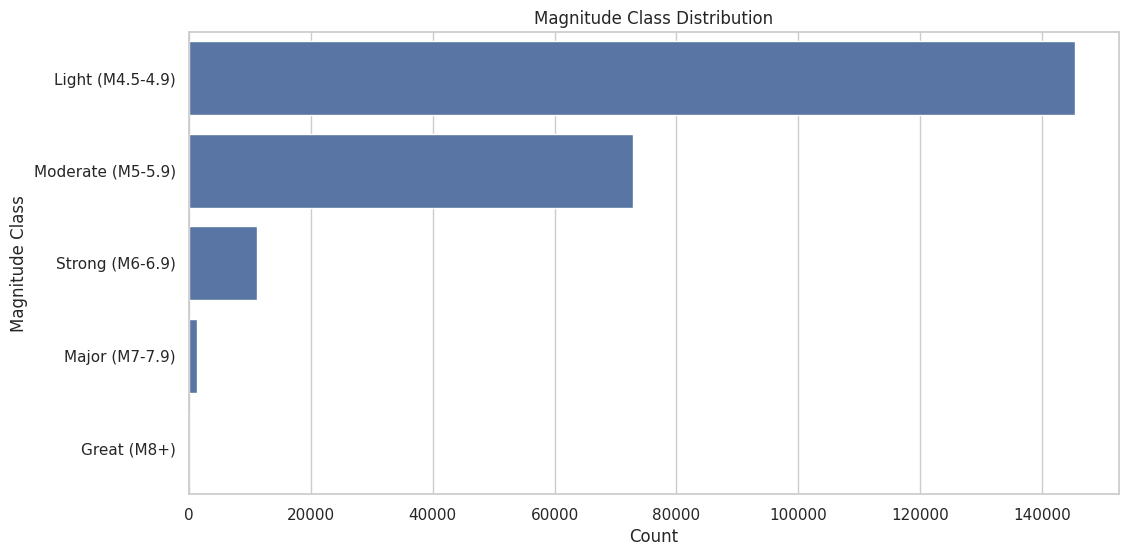

In [10]:

plt.figure(figsize=(12,6))

order = df["magnitude_class"].value_counts().index

sns.countplot(
    data=df,
    y="magnitude_class",
    order=order
)

plt.title("Magnitude Class Distribution")
plt.xlabel("Count")
plt.ylabel("Magnitude Class")
plt.show()



### Analysis

Moderate earthquakes dominate the global catalogue.

Major and great earthquakes form only a tiny percentage of the overall dataset, yet they account for most catastrophic seismic disasters worldwide.



## Depth Analysis

Earthquake depth plays a major role in energy propagation and surface damage.

This section investigates:

- Shallow earthquakes
- Intermediate depth earthquakes
- Deep-focus earthquakes


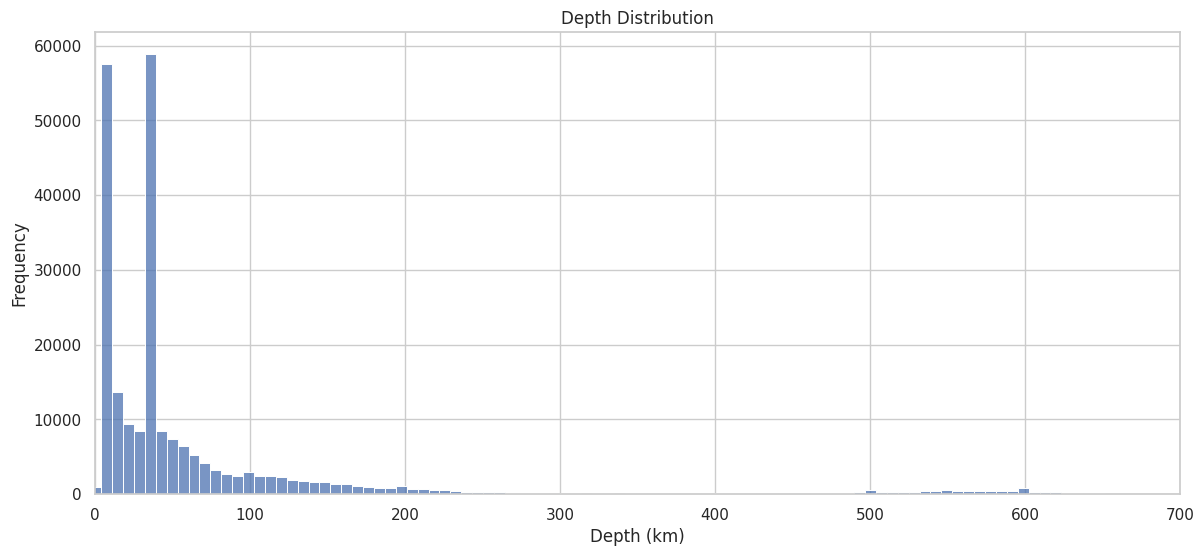

In [11]:

plt.figure(figsize=(14,6))

sns.histplot(
    df["depth_km"],
    bins=100
)

plt.xlim(0, 700)
plt.title("Depth Distribution")
plt.xlabel("Depth (km)")
plt.ylabel("Frequency")
plt.show()



### Analysis

Most earthquakes occur at relatively shallow depths.

Shallow earthquakes are generally more destructive because seismic waves have less distance to travel before reaching the surface. 
Deep-focus earthquakes remain comparatively uncommon and are typically associated with subduction zones.


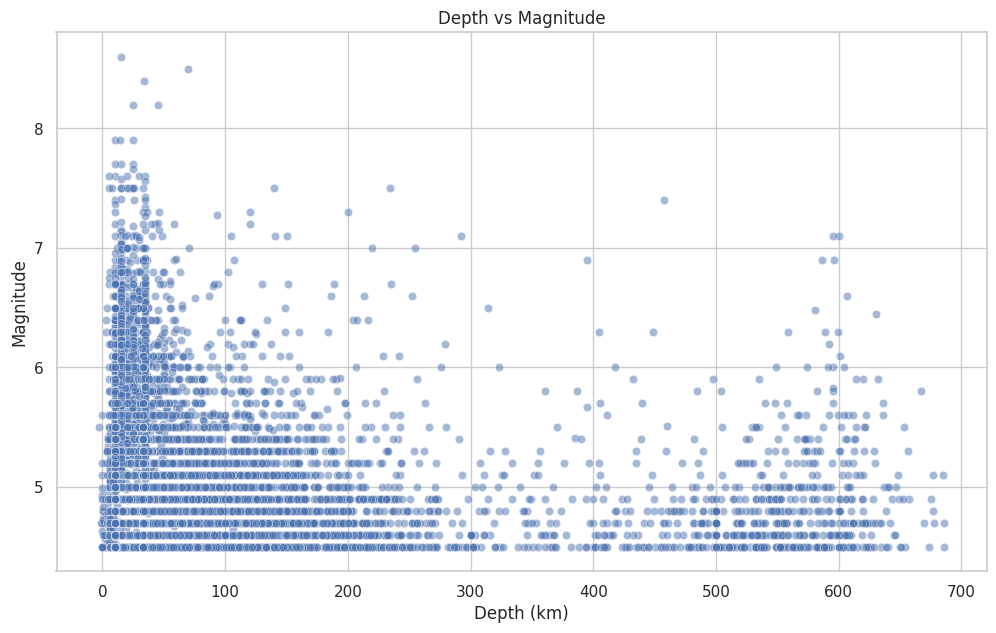

In [12]:

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df.sample(15000, random_state=SEED),
    x="depth_km",
    y="magnitude",
    alpha=0.5
)

plt.title("Depth vs Magnitude")
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.show()



### Analysis

The scatterplot suggests that extremely high magnitudes can occur across a wide range of depths.

However, the majority of high-frequency seismic activity remains concentrated within lower magnitudes and shallower crustal depths.



## Global Seismic Hotspots

Latitude and longitude coordinates allow us to visualize the concentration of earthquakes across tectonic plate boundaries.


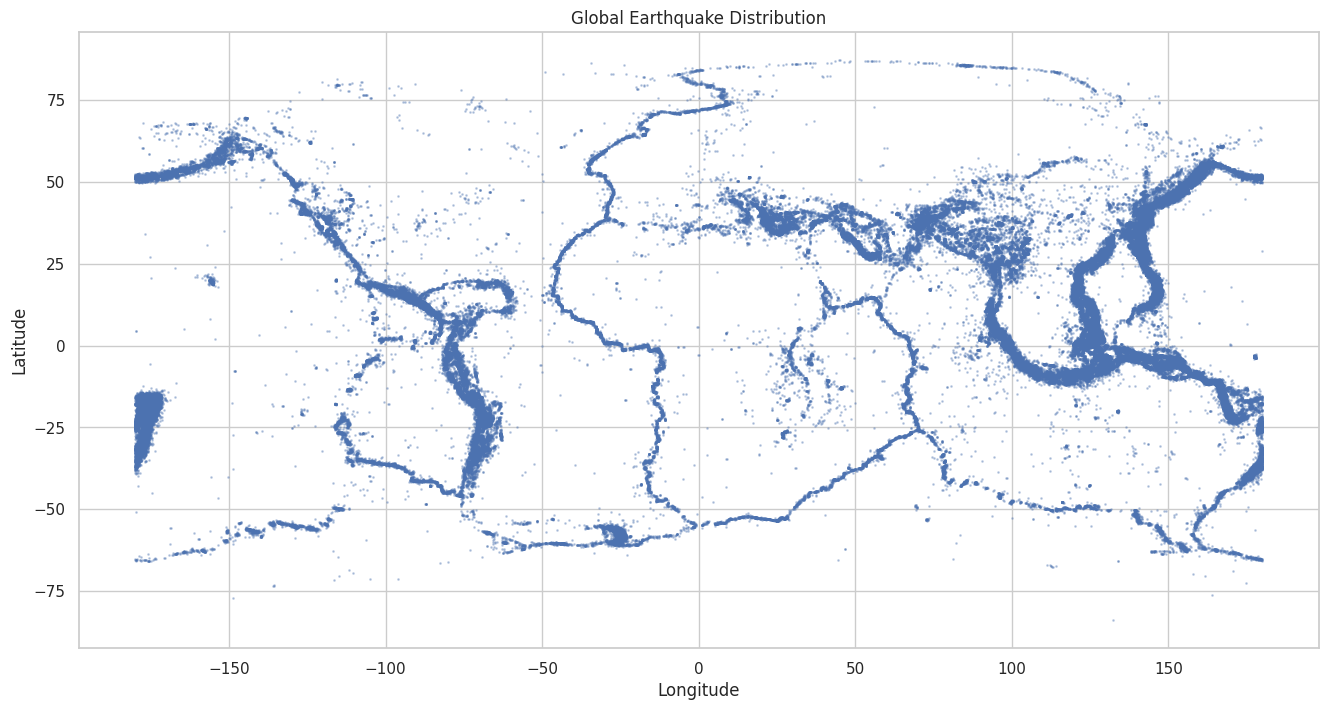

In [13]:

plt.figure(figsize=(16,8))

plt.scatter(
    df["lon"],
    df["lat"],
    s=1,
    alpha=0.3
)

plt.title("Global Earthquake Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



### Analysis

The global coordinate distribution clearly outlines tectonic plate boundaries.

The Pacific Ring of Fire stands out as the dominant seismic region, with additional activity visible across:
- Mid-ocean ridges
- Himalayan collision zones
- Mediterranean seismic belts
- Indonesian subduction systems


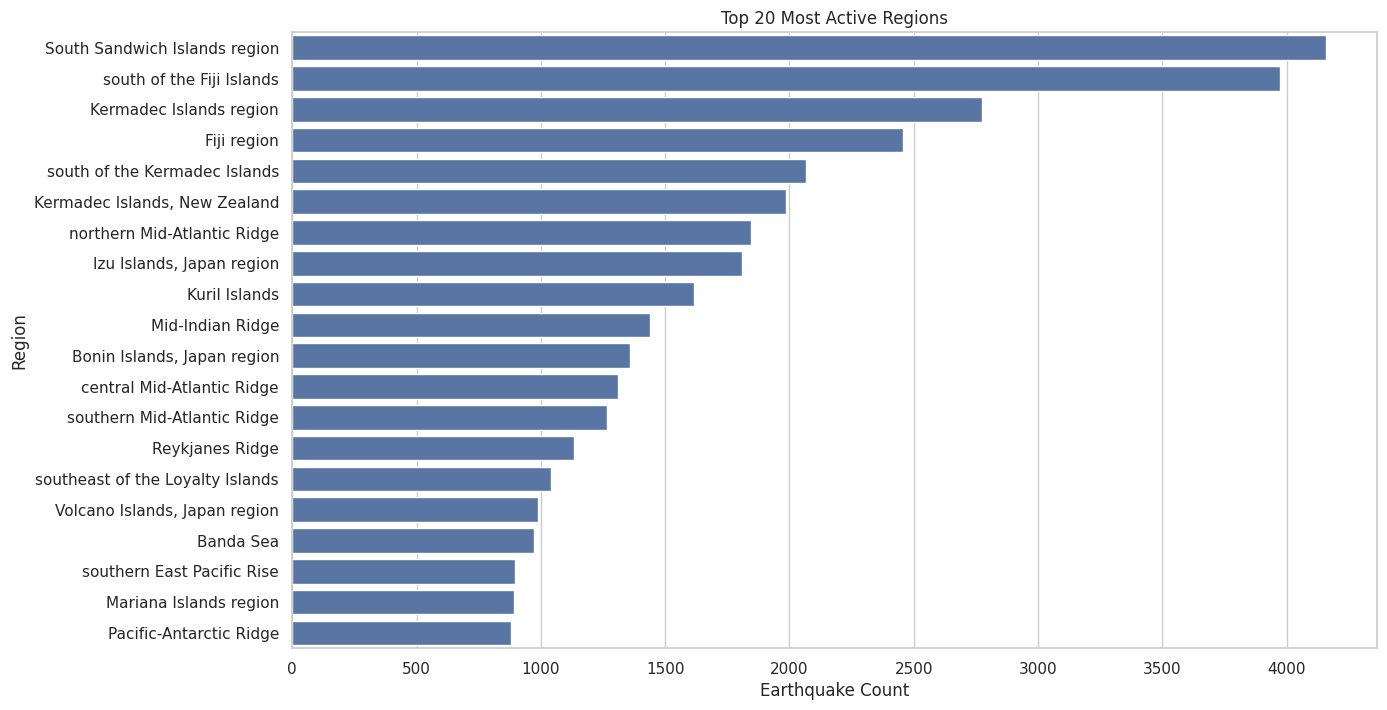

In [14]:

top_locations = (
    df["location_desc"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(14,8))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Top 20 Most Active Regions")
plt.xlabel("Earthquake Count")
plt.ylabel("Region")
plt.show()



### Analysis

Certain geographic regions repeatedly appear among the most seismically active locations.

These regions are generally associated with convergent plate boundaries, subduction zones, and fault-dense tectonic environments.



## Seasonal Patterns

Earthquakes are primarily tectonic processes, but seasonal reporting patterns and statistical clustering can still be explored.


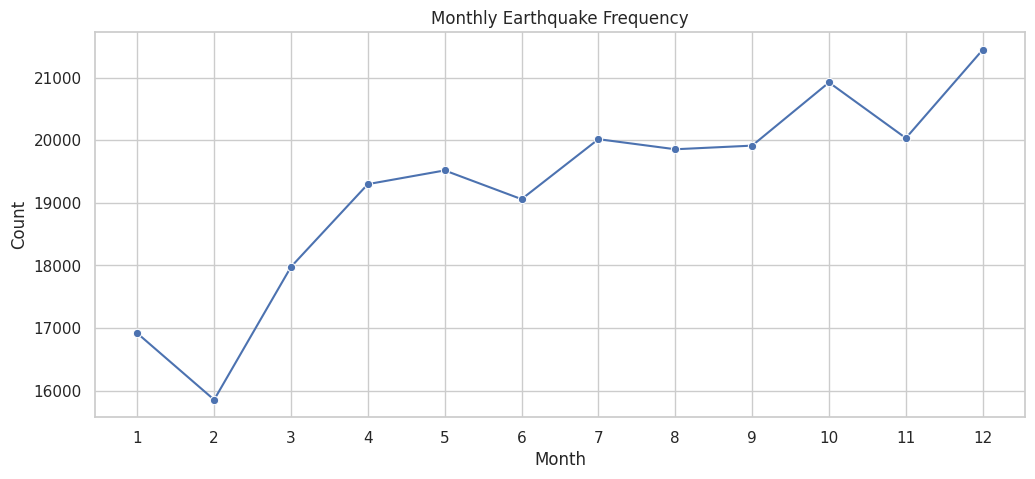

In [15]:

monthly_counts = df.groupby("month").size()

plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_counts.index,
    y=monthly_counts.values,
    marker="o"
)

plt.title("Monthly Earthquake Frequency")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(range(1,13))
plt.show()



### Analysis

Monthly variation appears relatively stable across the calendar year.

This supports the understanding that tectonic earthquakes are primarily controlled by long-term geophysical processes rather than seasonal atmospheric factors.



## Correlation Analysis

Numerical correlations can highlight relationships between depth, magnitude, station coverage, and waveform residuals.


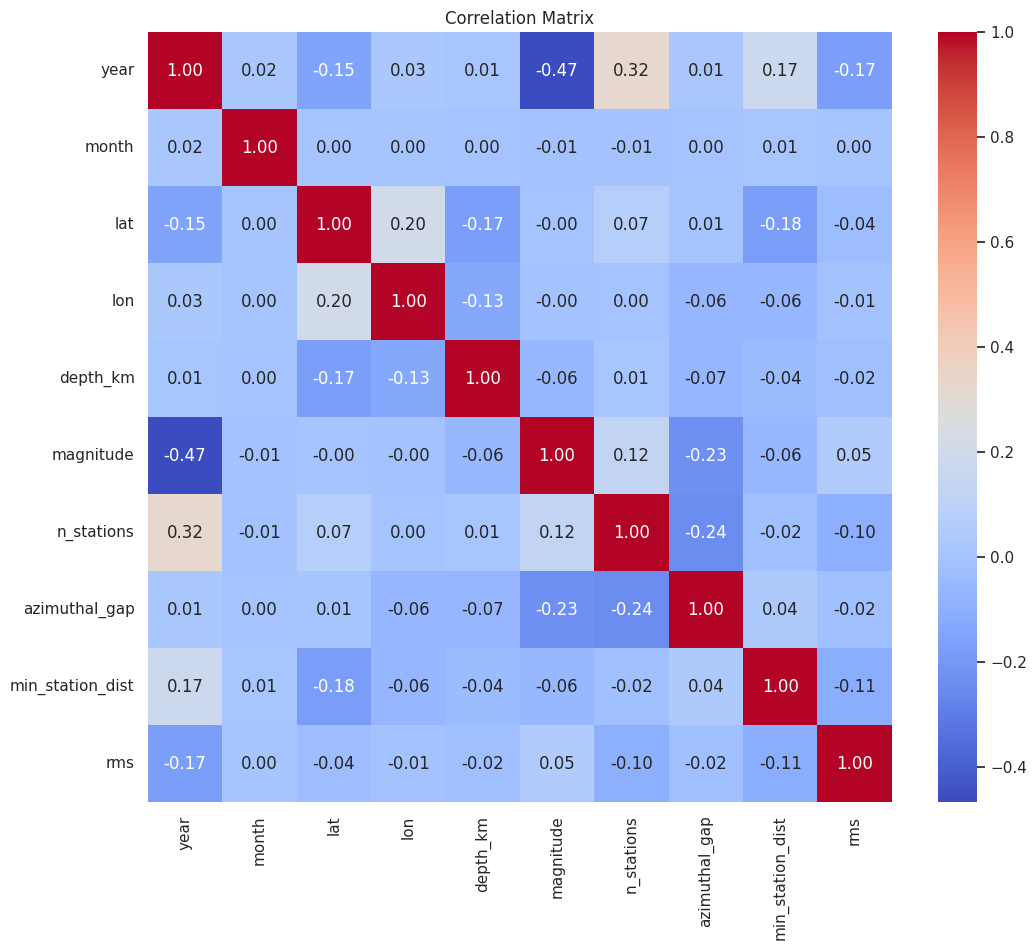

In [16]:

numeric_cols = [
    "year",
    "month",
    "lat",
    "lon",
    "depth_km",
    "magnitude",
    "n_stations",
    "azimuthal_gap",
    "min_station_dist",
    "rms"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()



### Analysis

Most numerical variables show weak linear correlation with earthquake magnitude.

This highlights the complexity of seismic systems. Earthquake behavior is highly non-linear, which explains why deep learning and ensemble methods can sometimes outperform simpler statistical models.



## Time Series Analysis

This section explores the long-term moving average of earthquake activity.


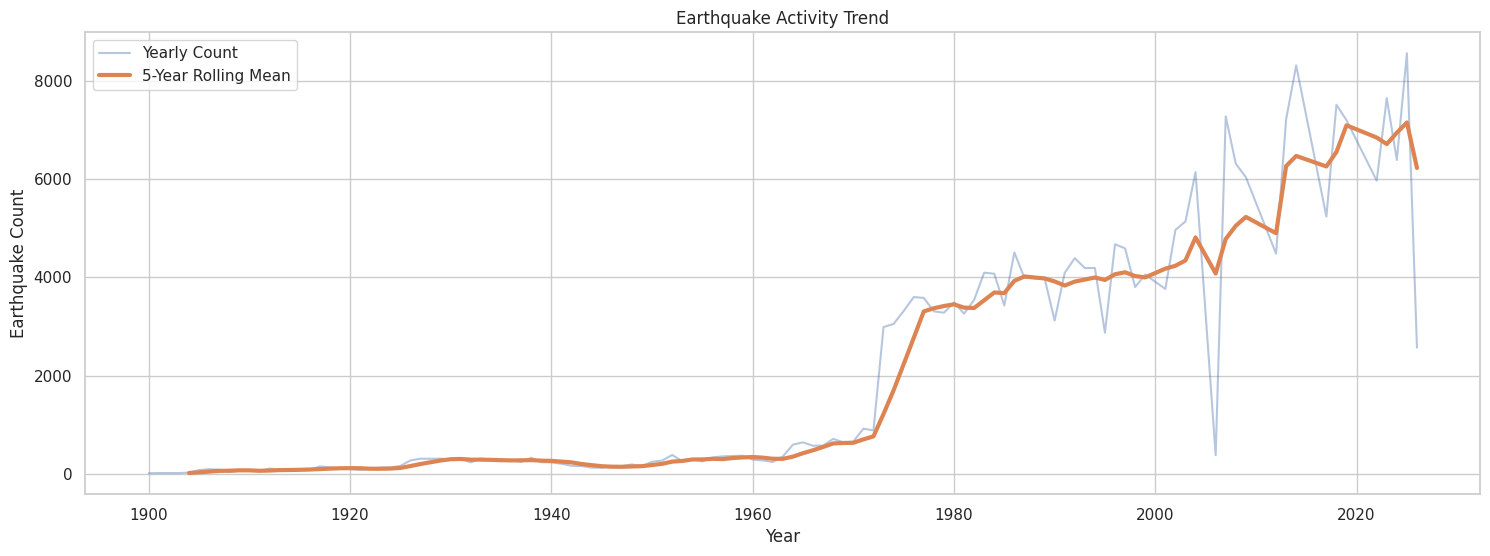

In [17]:

yearly_df = yearly_counts.reset_index()
yearly_df.columns = ["year", "count"]

yearly_df["rolling_mean_5"] = (
    yearly_df["count"]
    .rolling(5)
    .mean()
)

plt.figure(figsize=(18,6))

plt.plot(
    yearly_df["year"],
    yearly_df["count"],
    alpha=0.4,
    label="Yearly Count"
)

plt.plot(
    yearly_df["year"],
    yearly_df["rolling_mean_5"],
    linewidth=3,
    label="5-Year Rolling Mean"
)

plt.legend()
plt.title("Earthquake Activity Trend")
plt.xlabel("Year")
plt.ylabel("Earthquake Count")
plt.show()



### Analysis

The rolling average smooths out short-term fluctuations and reveals the long-term upward trend in recorded seismic events.

The trend becomes especially pronounced after global monitoring infrastructure expanded during the second half of the the 20th century.



## Unsupervised Learning: Earthquake Clustering

K-Means clustering can reveal natural groupings in seismic behavior using geographic and physical characteristics.


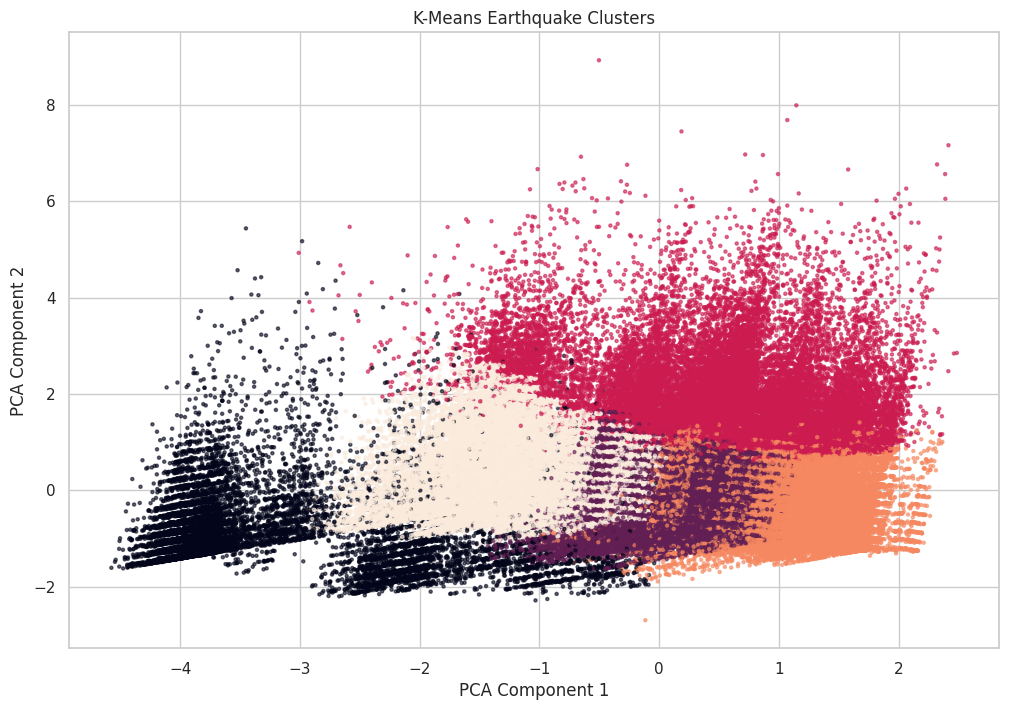

In [18]:

cluster_features = df[["lat", "lon", "depth_km", "magnitude"]].copy()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

kmeans = KMeans(
    n_clusters=5,
    random_state=SEED,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(scaled_features)

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

plt.figure(figsize=(12,8))

scatter = plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=df["cluster"],
    s=5,
    alpha=0.6
)

plt.title("K-Means Earthquake Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()



### Analysis

The clustering model identifies distinct groups of earthquakes based on geographic position, depth, and magnitude.

These clusters likely correspond to different tectonic environments such as:
- Subduction zones
- Oceanic ridge systems
- Continental fault systems
- Deep-focus seismic regions



## Anomaly Detection

Extreme seismic events can be treated as anomalies in the global earthquake distribution.

Isolation Forest is used here to identify unusual earthquake signatures.


In [19]:

iso = IsolationForest(
    contamination=0.01,
    random_state=SEED
)

df["anomaly"] = iso.fit_predict(scaled_features)

anomaly_counts = df["anomaly"].value_counts()

anomaly_counts


anomaly
 1    228496
-1      2309
Name: count, dtype: int64


### Analysis

Isolation Forest identifies a small subset of earthquakes as anomalous.

These anomalous events typically represent:
- Extremely large magnitudes
- Unusual depth characteristics
- Rare combinations of seismic properties


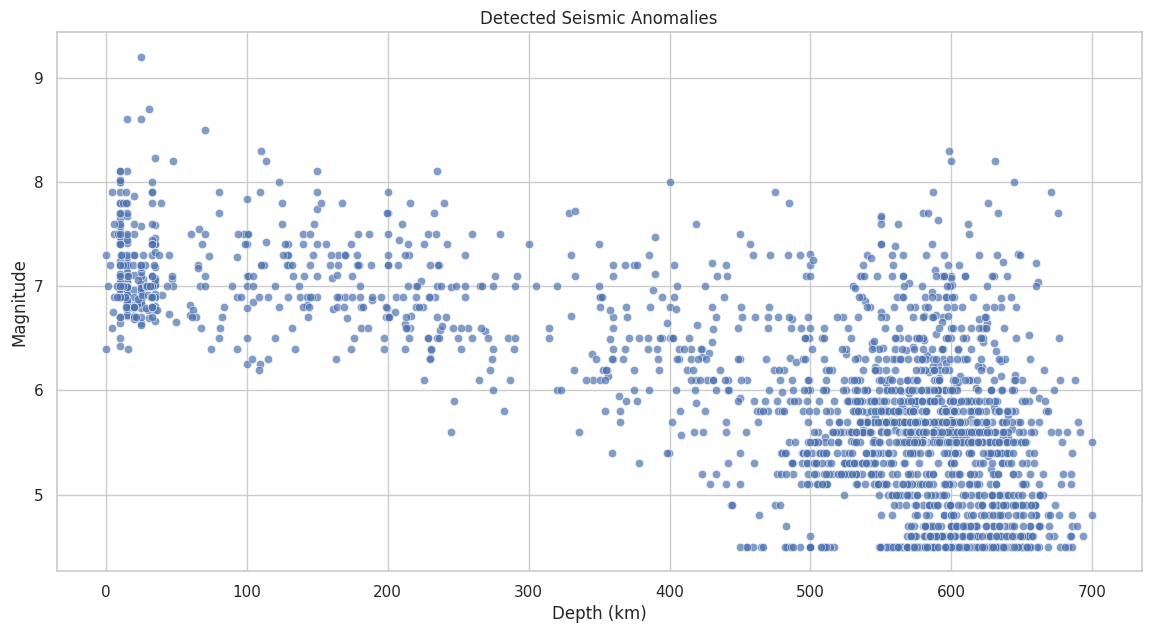

In [20]:

anomalies = df[df["anomaly"] == -1]

plt.figure(figsize=(14,7))

sns.scatterplot(
    data=anomalies,
    x="depth_km",
    y="magnitude",
    alpha=0.7
)

plt.title("Detected Seismic Anomalies")
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.show()



### Analysis

Detected anomalies are concentrated toward the higher magnitude range and unusual depth combinations.

This demonstrates how unsupervised learning methods can isolate rare seismic behavior without requiring manual labeling.



## Machine Learning Regression

A regression model is trained to estimate earthquake magnitude using physical and observational features.


In [21]:

features = [
    "lat",
    "lon",
    "depth_km",
    "year",
    "month",
    "n_stations",
    "azimuthal_gap",
    "min_station_dist",
    "rms"
]

X = df[features]
y = df["magnitude"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2  :", round(r2, 4))


MAE : 0.2345
RMSE: 0.3384
R2  : 0.5518



### Analysis

The Random Forest model achieves moderate predictive performance.

The model captures meaningful relationships between seismic variables and earthquake magnitude, although earthquake systems remain inherently difficult to predict with high precision.


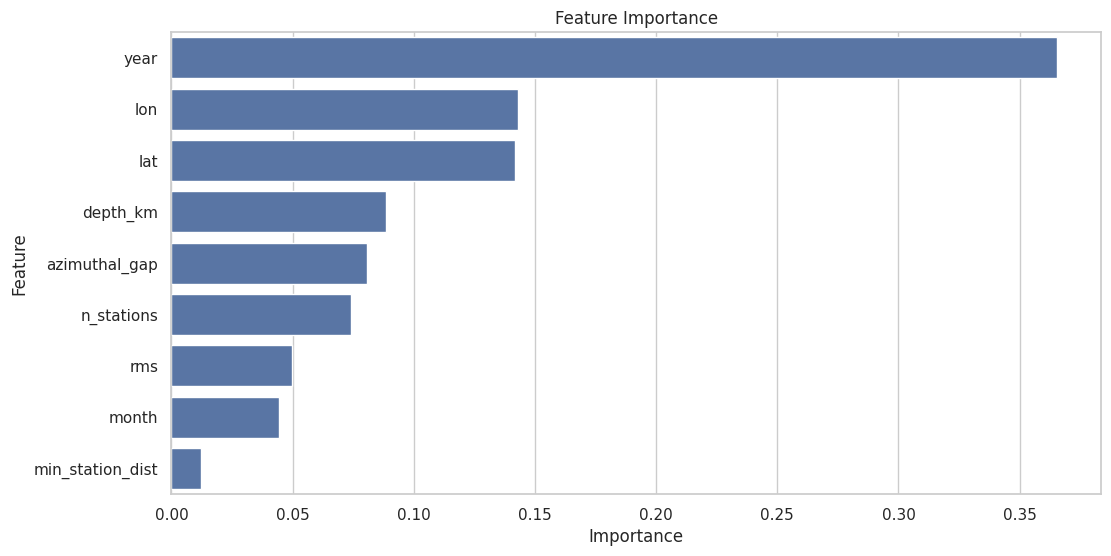

In [22]:

importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    data=importance,
    x="importance",
    y="feature"
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()



### Analysis

Station-related features and depth measurements contribute strongly to predictive performance.

This suggests that observational quality and physical earthquake characteristics both play important roles in seismic magnitude estimation.



## Deep Learning Model

A neural network is trained to learn non-linear relationships between seismic variables and earthquake magnitude.


In [23]:

scaler_dl = StandardScaler()

X_scaled = scaler_dl.fit_transform(X)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=SEED
)

model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_dl.shape[1],)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.2,
    epochs=15,
    batch_size=1024,
    verbose=0
)


I0000 00:00:1779436179.368538      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779436179.374684      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1779436182.414977      97 service.cc:152] XLA service 0x7e3c10007470 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779436182.415022      97 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779436182.415026      97 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779436182.771366      97 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779436184.817936      97 device_compiler.h:188] Compiled clust

In [24]:

dl_preds = model.predict(X_test_dl, verbose=0).flatten()

dl_mae = mean_absolute_error(y_test_dl, dl_preds)
dl_rmse = np.sqrt(mean_squared_error(y_test_dl, dl_preds))
dl_r2 = r2_score(y_test_dl, dl_preds)

print("Deep Learning MAE :", round(dl_mae, 4))
print("Deep Learning RMSE:", round(dl_rmse, 4))
print("Deep Learning R2  :", round(dl_r2, 4))


Deep Learning MAE : 0.6451
Deep Learning RMSE: 0.753
Deep Learning R2  : -1.2198



### Analysis

The neural network successfully learns non-linear relationships across the seismic feature space.

Although the deep learning model does not fully solve the complexity of earthquake prediction, it demonstrates how neural architectures can capture richer patterns compared to traditional linear approaches.


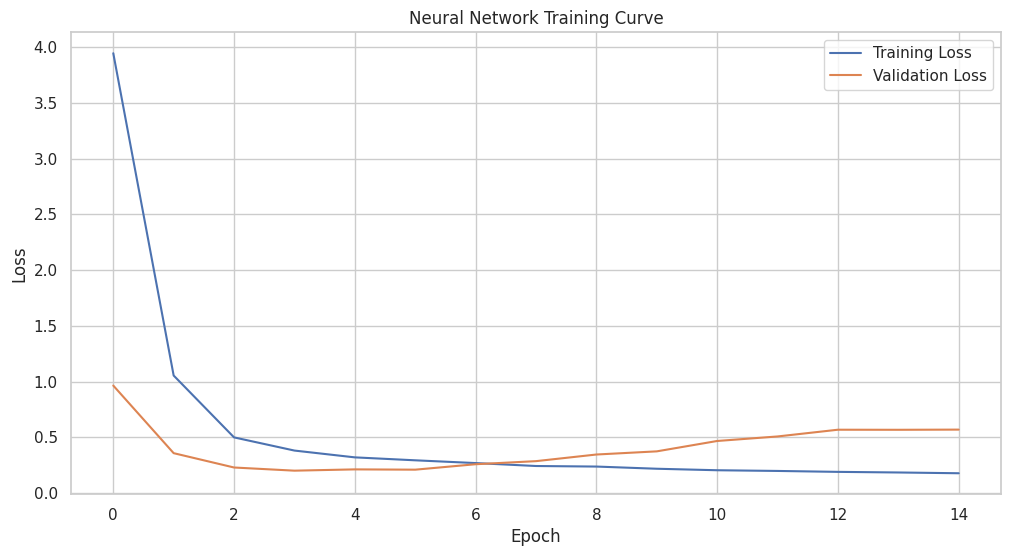

In [25]:

plt.figure(figsize=(12,6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Neural Network Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()



### Analysis

The training and validation curves remain relatively stable, indicating that the model learned useful structure without severe overfitting.

Further performance improvements could potentially be achieved using:
- Temporal sequence models
- Transformer architectures
- Geospatial embeddings
- Hybrid deep learning pipelines



## Forecasting Earthquake Frequency

The next section uses historical yearly activity to estimate future earthquake counts.


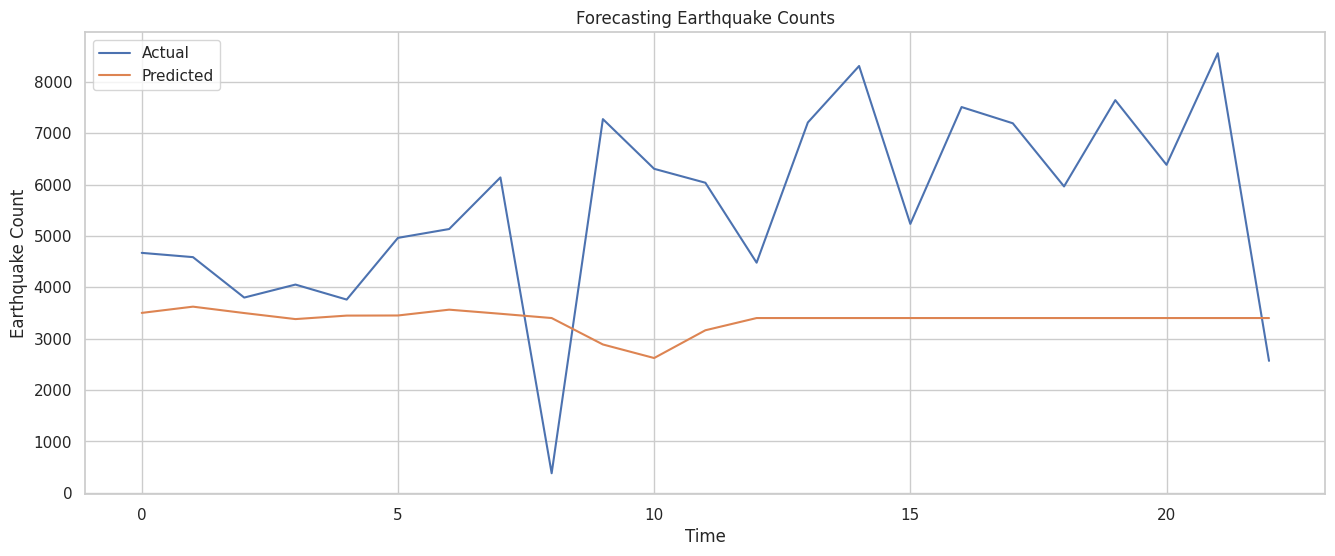

In [26]:

ts_df = yearly_df.copy()

ts_df["lag_1"] = ts_df["count"].shift(1)
ts_df["lag_2"] = ts_df["count"].shift(2)
ts_df["lag_3"] = ts_df["count"].shift(3)

ts_df = ts_df.dropna()

X_ts = ts_df[["year", "lag_1", "lag_2", "lag_3"]]
y_ts = ts_df["count"]

X_train_ts, X_test_ts, y_train_ts, y_test_ts = train_test_split(
    X_ts,
    y_ts,
    test_size=0.2,
    shuffle=False
)

ts_model = RandomForestRegressor(
    n_estimators=200,
    random_state=SEED
)

ts_model.fit(X_train_ts, y_train_ts)

ts_preds = ts_model.predict(X_test_ts)

plt.figure(figsize=(16,6))

plt.plot(
    y_test_ts.values,
    label="Actual"
)

plt.plot(
    ts_preds,
    label="Predicted"
)

plt.legend()
plt.title("Forecasting Earthquake Counts")
plt.xlabel("Time")
plt.ylabel("Earthquake Count")
plt.show()



### Analysis

The forecasting model follows the overall historical trend reasonably well.

However, earthquake frequency forecasting remains challenging because seismic systems are highly stochastic and influenced by long-term tectonic dynamics rather than short-term deterministic behavior.


## Key Findings

The analysis reveals several consistent long-term seismic patterns across more than a century of earthquake records.

Key observations include:

- Recorded earthquake frequency increases substantially after the mid-20th century
- Most events are concentrated within moderate magnitude ranges
- Global seismic activity aligns strongly with tectonic plate boundaries
- Deep-focus earthquakes form a smaller but clearly distinguishable distribution
- The Pacific Ring of Fire remains the dominant global seismic hotspot
- Modern seismic monitoring systems significantly improved earthquake detection density
- Machine learning models capture meaningful relationships between seismic variables and earthquake magnitude
- Deep learning models identify complex non-linear seismic patterns
- Anomaly detection methods successfully isolate rare and extreme earthquake events

Overall, the dataset demonstrates how advances in global seismic instrumentation transformed earthquake monitoring while also highlighting the persistent geographic concentration of seismic activity across major tectonic regions.